# EverFlavor AI - Ingredient Knowledge: Names, Substitutions, Pairings and Shelf Life

**Team:** EverGlow
**Course:** ITAI 2277
**Project:** EverFlavor AI - Multi-Agent Recipe and Nutrition System

> **Run time** (measured on a laptop CPU, downloads already saved): under 1 minute.
> **First run:** the Wikidata name lookups and the FoodKeeper download can take 10-30 minutes (estimate); answers are saved and reused. Colab's free runtime takes about as long, or a little longer.

> **Status: built.** Every section runs and saves its table; the code is in `src/everflavor/knowledge.py`
> and is tested in `tests/test_knowledge.py`. The ambiguous name matches and a sample of the substitutions
> still need a hand check by the team (section 6) before any agent relies on them.
> "Run all" downloads only what is missing (FoodKeeper, Wikidata answers) and reuses saved copies after that.

---

## Purpose

Notebook 01 knows each recipe's ingredients by one English name. The agents need to know more about
each ingredient:

- **Names in other languages and regions** ("coriander" / "cilantro" / "dhania"; "aubergine" / "eggplant";
  "bell pepper" / "capsicum"). This is what makes adding a new region cheap: a recipe or a store label in
  another language maps to the same ingredient.
- **Substitutions:** what to use when an ingredient is missing or not allowed, and what changes (flavor,
  texture, allergens).
- **Pairings:** which ingredients are often used together, and in which cuisines.
- **Shelf life:** how long an ingredient keeps in the pantry, fridge and freezer.

**Safety rule:** a substitution is only suggested after the substitute is checked against the person's
restrictions with the same flag rules as notebook 01 (`everflavor.flags`). A substitution never removes a
caution on its own.

## Inputs and outputs

| | File | Made by |
|---|---|---|
| Input | `data/interim/recipes_all.parquet` (ingredient lists, cuisines, countries) | Notebook 01 (section 5.11) |
| Input | Food.com `RAW_interactions.csv` (1.1 million reviews) | Notebook 01 (section 2.4.2), reused from the kagglehub cache |
| Input | Wikidata (SPARQL query service, CC0, no key) | Section 2, answers saved in `data/raw/wikidata_cache/` |
| Input | USDA FoodKeeper (CC0, no key) | Section 5, saved in `data/raw/foodkeeper/` (from USDA, or the Internet Archive copy when USDA refuses the download) |
| Output | `data/processed/ingredient_names.parquet` (each ingredient's names in the pilot languages, with the Wikidata item) | Notebook 04 (section 2), rebuilt on every run, not stored in GitHub |
| Output | `data/processed/ingredient_substitutions.parquet` (swaps reviewers made, with the flags each removes or adds, plus alcohol-free swaps) | Notebook 04 (section 3), rebuilt on every run, not stored in GitHub |
| Output | `data/processed/ingredient_pairings.parquet` (ingredient pairs scored by PMI, overall, per cuisine family and per country) | Notebook 04 (section 4), rebuilt on every run, not stored in GitHub |
| Output | `data/processed/ingredient_shelf_life.parquet` (USDA storage times in days for each matched ingredient) | Notebook 04 (section 5), rebuilt on every run, not stored in GitHub |

## Contents

1. Setup
2. Ingredient Names Across Languages (Wikidata)
3. Substitutions (Food.com reviews)
4. Pairings (from our own recipes)
5. Shelf Life (USDA FoodKeeper)
6. Team Decisions and Next Steps

---

## 1. Setup

The same setup as notebooks 01 and 02: it works unchanged in Google Colab, VS Code and Antigravity.

In [1]:
# %pip (not !pip) installs into the Python that runs this notebook,
# in Colab and in local kernels (VS Code / Antigravity / JupyterLab).
%pip install -q kagglehub requests pandas pyarrow scipy scikit-learn matplotlib tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
import importlib.util
import os
import sys
from pathlib import Path

import pandas as pd

# -------------------------------------------------------
# 1. Where is this notebook running? Move to the project folder
#    (the one that holds notebooks/ and data/), as in notebook 01.
# -------------------------------------------------------
IN_COLAB = importlib.util.find_spec("google.colab") is not None   # only exists in Colab


def find_project_root(start):
    # Return the nearest folder at or above `start` with notebooks/ and data/, or None
    start = Path(start).resolve()
    for folder in [start, *start.parents]:
        if (folder / "notebooks").is_dir() and (folder / "data").is_dir():
            return folder
    return None

PROJECT_ROOT = find_project_root(Path.cwd())
if PROJECT_ROOT is None and IN_COLAB and Path("/content/The-EverFlavor-AI").is_dir():
    PROJECT_ROOT = Path("/content/The-EverFlavor-AI")
if PROJECT_ROOT is None:
    PROJECT_ROOT = Path.cwd()
os.chdir(PROJECT_ROOT)

# -------------------------------------------------------
# 2. The project's code (src/everflavor). If the notebook was opened on its
#    own, the missing files are downloaded from GitHub (temporary name
#    first, __init__.py last), exactly as in notebook 01.
# -------------------------------------------------------
SRC_DIR = PROJECT_ROOT / "src"
EVERFLAVOR_MODULES = ["__init__", "agent_tools", "calories", "charts", "checks", "cooking", "crew",
                      "cuisine", "diets", "environment", "evaluation", "features", "flags", "freshness", "ingredients",
                      "knowledge", "llm", "nutrition", "nutrition_quality", "parsing", "pipeline",
                      "progress", "recommend", "reporting", "review", "safety", "seasons", "sources",
                      "stores", "variants"]
EVERFLAVOR_URL = "https://raw.githubusercontent.com/Chloe-Tu2/The-EverFlavor-AI/main/src/everflavor/"
EVERFLAVOR_DIR = SRC_DIR / "everflavor"
missing_modules = [m for m in EVERFLAVOR_MODULES if not (EVERFLAVOR_DIR / f"{m}.py").exists()]
if missing_modules:
    import urllib.request
    EVERFLAVOR_DIR.mkdir(parents=True, exist_ok=True)
    for module in sorted(missing_modules, key=lambda m: m == "__init__"):
        partial = EVERFLAVOR_DIR / f"{module}.py.part"
        urllib.request.urlretrieve(f"{EVERFLAVOR_URL}{module}.py", partial)
        partial.replace(EVERFLAVOR_DIR / f"{module}.py")
    print(f"Downloaded {len(missing_modules)} project code file(s) (src/everflavor) from GitHub.")
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from everflavor.environment import short_path

REFRESH_DOWNLOADS = False   # True downloads every source again instead of using the saved copy
SPLIT_FILES = {s: Path(f"data/processed/recipes_{s}.parquet") for s in ["train", "val", "test"]}
ALL_RECIPES_FILE = Path("data/interim/recipes_all.parquet")
WIKIDATA_CACHE = Path("data/raw/wikidata_cache")
FOODKEEPER_DIR = Path("data/raw/foodkeeper")
NAMES_FILE = Path("data/processed/ingredient_names.parquet")
SUBSTITUTIONS_FILE = Path("data/processed/ingredient_substitutions.parquet")
PAIRINGS_FILE = Path("data/processed/ingredient_pairings.parquet")
SHELF_LIFE_FILE = Path("data/processed/ingredient_shelf_life.parquet")
for folder in [WIKIDATA_CACHE, FOODKEEPER_DIR, Path("data/processed")]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Runtime        : {'Google Colab' if IN_COLAB else 'Local Jupyter (VS Code / Antigravity / JupyterLab)'}")
print(f"Python         : {sys.version.split()[0]}")
print(f"Project folder : {short_path(PROJECT_ROOT)}")
missing_inputs = [str(p) for p in [*SPLIT_FILES.values(), ALL_RECIPES_FILE] if not p.exists()]
if missing_inputs:
    print("\nMISSING notebook 01 outputs:", ", ".join(missing_inputs))
    print("Run notebook 01 first (all of Week 5), then run this notebook again.")
else:
    print("Notebook 01 outputs found.")

Runtime        : Local Jupyter (VS Code / Antigravity / JupyterLab)
Python         : 3.12.10
Project folder : ~\Downloads\jupiter-exploration\The-EverFlavor-AI
Notebook 01 outputs found.


In [3]:
import kagglehub
import matplotlib.pyplot as plt

from everflavor.charts import label_bars, set_chart_style, show_figure
from everflavor.knowledge import (
    ALCOHOL_FREE_SWAPS,
    download_foodkeeper,
    foodkeeper_table,
    ingredient_pairings,
    match_shelf_life,
    names_in_languages,
    substitution_effects,
    substitutions_from_reviews,
    wikidata_matches,
)

set_chart_style()
pd.set_option("display.max_colwidth", 90)
recipes = pd.read_parquet(ALL_RECIPES_FILE, columns=["recipe_id", "ingredient_list", "cuisine_family", "origin_country"])
ingredient_counts = pd.Series([i for items in recipes["ingredient_list"] for i in items]).value_counts()
print(f"{len(recipes):,} recipes, {len(ingredient_counts):,} different ingredient names")

291,755 recipes, 46,801 different ingredient names


---

## 2. Ingredient Names Across Languages (Wikidata)

**Source:** Wikidata, through its SPARQL query service. Wikidata is **CC0** (no restrictions). Each food
item has labels and aliases in many languages ("Coriandrum sativum": cilantro, coriander, dhania, 香菜,
كزبرة ...).

**Steps:**

1. Take the ingredient names used in at least `NAME_MIN_RECIPES` recipes.
2. Find each name's Wikidata item by English label or alias. Candidates are ranked: an English label before
   an alias, then by the food words in their description ("spice", "species of plant") minus non-food words
   ("gene", "film"), so "egg" finds the food, not a fruit-fly gene. A name with several food candidates is
   marked `ranked`. A name with no match is tried again without its first words ("ground cinnamon" ->
   "cinnamon", "all-purpose flour" -> "flour") and marked `head`. Both go to the **hand-check list**, like
   the flag review.
3. Download labels and aliases in the pilot languages (`PILOT_LANGUAGES`, a team decision in section 6).

**Limits:** the query service asks for a descriptive User-Agent and stops queries after 60 seconds, so names
are queried in batches of 40, one second apart, and every answer is saved in `data/raw/wikidata_cache/`.

**Second source to compare later:** the Open Food Facts ingredient taxonomy (names in many languages, and
vegan / vegetarian properties); its exact license is to be confirmed first.

In [4]:
NAME_MIN_RECIPES = 100   # team decision (section 6)
PILOT_LANGUAGES = ["en", "es", "fr", "it", "hi", "zh", "ja", "ar", "am", "ko", "vi", "fa"]  # team decision

common_names = ingredient_counts[ingredient_counts >= NAME_MIN_RECIPES].index.tolist()
name_matches = wikidata_matches(common_names, WIKIDATA_CACHE, refresh=REFRESH_DOWNLOADS)
print(f"{len(common_names):,} ingredients used in at least {NAME_MIN_RECIPES} recipes")
print(name_matches["match"].value_counts().rename("ingredients").to_string())

names_long = names_in_languages(name_matches["wikidata_id"].dropna().tolist(), PILOT_LANGUAGES, WIKIDATA_CACHE,
                                refresh=REFRESH_DOWNLOADS)
ingredient_names = name_matches[["ingredient", "wikidata_id", "match"]].merge(names_long, on="wikidata_id")
ingredient_names.to_parquet(NAMES_FILE, index=False)
print(f"\nSaved {len(ingredient_names):,} names in {ingredient_names['language'].nunique()} languages "
      f"for {ingredient_names['ingredient'].nunique():,} ingredients to {NAMES_FILE}")

Wikidata names:   0%|          | 0/47 [00:00<?, ?it/s]

Wikidata names:   0%|          | 0/12 [00:00<?, ?it/s]

1,863 ingredients used in at least 100 recipes
match
head      913
exact     447
none      352
ranked    151


Wikidata labels:   0%|          | 0/16 [00:00<?, ?it/s]


Saved 30,970 names in 12 languages for 1,511 ingredients to data\processed\ingredient_names.parquet


In [5]:
# The same ingredient in other languages: one label per language (aliases add more spellings)
examples = ["cilantro", "eggplant", "chickpea", "cumin", "ginger", "rice"]
labels = ingredient_names[(ingredient_names["kind"] == "label") & ingredient_names["ingredient"].isin(examples)]
labels.pivot_table(index="ingredient", columns="language", values="name", aggfunc="first").reindex(
    columns=PILOT_LANGUAGES)

language,en,es,fr,it,hi,zh,ja,ar,am,ko,vi,fa
ingredient,,,,,,,,,,,,
chickpea,chickpea,garbanzo,pois chiche,cece,NaN,NaN,ひよこ豆,حمص شائع,NaN,NaN,NaN,NaN
cilantro,cilantro,cilantro,feuille de coriandre,foglie di coriandolo,धनिया,NaN,シラントロ,NaN,NaN,NaN,NaN,NaN
cumin,Cuminum cyminum,Cuminum cyminum,cumin,Cuminum cyminum,जीरा,孜然,クミン,كمون,NaN,쿠민,Thì là Ai Cập,زیره سبز
eggplant,eggplant,berenjena,aubergine,melanzana,NaN,茄子,ナス,باذنجان,NaN,NaN,NaN,NaN
ginger,ginger,jengibre,gingembre,zenzero,अदरक,生姜,ショウガ,زنجبيل,ዝንጅብል,생강,Nấu ăn:Gừng,زنجبیل
rice,rice,arroz,riz,riso,चावल,稻,米,أرز,ሩዝ,쌀,gạo,برنج


In [6]:
# Hand-check list: several food items fit the name ("ranked"), or only its last words matched ("head");
# the best-ranked item is kept until a person confirms it
name_matches[name_matches["match"].isin(["ranked", "head"])].sample(15, random_state=0)

,ingredient,wikidata_id,description,n_candidates,match
368,provolone cheese,Q10943,"yellow or white, creamy or solid food made from the pressed curds of milk",3,head
1741,red pepper sauce,Q522171,chili pepper-based condiment,1,head
1239,uncooked rice,Q5090,cereal grain and staple food,2,head
977,pimento stuffed olive,Q1621080,fruit of the olive tree,7,head
1520,hot paprika,Q3127593,spice made from ground red peppers,2,head
1248,frozen lemonade concentrate,Q1355665,form of substance which has had the majority of its base component (in the case of a l...,2,head
500,red kidney bean,Q18175531,variety of common bean with reddish seeds and kidney shape,1,head
1774,crisp rice cereal,Q12117,grass cultivated for its edible grain,3,head
1141,brown onion,Q3406628,"culinary ingredient, type of vegetable",6,head
416,beet,Q165437,cultivar group of the beet plant (no colour indication),4,ranked


---

## 3. Substitutions (Food.com Reviews)

**Source:** Food.com reviews (`RAW_interactions.csv`, about 1.1 million reviews, already downloaded by
notebook 01). Reviewers often write what they changed: "I used Greek yogurt instead of sour cream",
"substituted honey for the sugar".

**Steps:**

1. Find swap sentences with four patterns ("used X instead of Y", "substituted X for Y", "replaced Y with X",
   "swapped Y for X").
2. Clean X and Y with the same ingredient cleaner as notebook 01, and keep a pair **only when Y is in that
   recipe's ingredient list**. This filters out most wrong matches ("used less time instead of ...").
3. Count each pair and the average rating of the reviews that made it (Food.com's 0 means "no rating" and
   is left out).
4. Add what each swap changes: the restriction flags it removes and adds (`everflavor.flags`), for example
   butter -> olive oil removes `contains_dairy`, water -> chicken broth adds `contains_meat`.

**Alcohol-free swaps:** recipes with `contains_alcohol` or `contains_alcohol_extract` also get the
alcohol-free substitutes in `ALCOHOL_FREE_SWAPS` (wine -> stock with a little vinegar; mirin -> rice vinegar
with sugar; vanilla extract -> alcohol-free flavoring), next to notebook 02's estimate of the alcohol left
after cooking.

**Hand check:** a blind sample of pairs, as with the flags, before any agent uses them (section 6).

In [7]:
SUBSTITUTION_MIN_REVIEWS = 2   # a swap must be described in at least this many reviews

foodcom_path = Path(kagglehub.dataset_download("shuyangli94/food-com-recipes-and-user-interactions"))
reviews = pd.read_csv(foodcom_path / "RAW_interactions.csv", usecols=["recipe_id", "rating", "review"])
swaps = substitution_effects(substitutions_from_reviews(reviews, recipes, min_reviews=SUBSTITUTION_MIN_REVIEWS))
swaps["source"] = "food.com reviews"
guidance = ALCOHOL_FREE_SWAPS.assign(source="alcohol-free guidance")
substitutions = pd.concat([swaps, substitution_effects(guidance)], ignore_index=True)
substitutions.to_parquet(SUBSTITUTIONS_FILE, index=False)
print(f"{len(reviews):,} reviews read; {len(swaps):,} swaps described in at least {SUBSTITUTION_MIN_REVIEWS} reviews")
print(f"Saved {len(substitutions):,} substitutions to {SUBSTITUTIONS_FILE}")
swaps.head(15)[["original", "substitute", "n_reviews", "mean_rating", "flags_removed", "flags_added"]]

1,132,367 reviews read; 2,163 swaps described in at least 2 reviews
Saved 2,173 substitutions to data\processed\ingredient_substitutions.parquet


,original,substitute,n_reviews,mean_rating,flags_removed,flags_added
0,sugar,splenda,624,4.80,,
1,margarine,butter,277,4.76,,contains_dairy
2,butter,olive oil,270,4.78,contains_dairy,
3,walnut,pecan,185,4.77,,
4,water,chicken broth,153,4.66,,contains_meat contains_poultry
5,shortening,butter,134,4.69,,contains_dairy
6,butter,margarine,120,4.74,contains_dairy,
7,garlic salt,garlic powder,119,4.72,contains_added_salt,
8,water,milk,117,4.60,,contains_dairy
9,ground beef,ground turkey,111,4.78,contains_beef contains_red_meat,contains_poultry


In [8]:
# Swaps that remove an allergen or a restricted ingredient, the ones the agents need most
for flag in ["contains_dairy", "contains_egg", "contains_gluten", "contains_pork"]:
    found = swaps[[flag in str(f).split() for f in swaps["flags_removed"]]]
    top = ", ".join(f"{o} -> {s} ({n})" for o, s, n in found[["original", "substitute", "n_reviews"]].head(5).itertuples(index=False))
    print(f"{flag:16s} {top}")

contains_dairy   butter -> olive oil (270), butter -> margarine (120), butter -> coconut oil (51), butter -> oil (50), butter -> applesauce (44)
contains_egg     mayonnaise -> sour cream (7), egg -> flax (6), egg -> egg replacer (4), egg -> ener-g egg replacer (4), egg -> cup (3)
contains_gluten  flour -> cornstarch (25), flour -> corn starch (7), flour -> corn tortilla (7), beer -> water (6), wheat germ -> flax seed (6)
contains_pork    ground pork -> ground turkey (16), bacon -> olive oil (6), bacon grease -> butter (6), lard -> butter (6), bacon -> chicken (5)


---

## 4. Pairings (From Our Own Recipes)

No new download: the recipes from notebook 01 already show which ingredients are used together. For each
pair of ingredients the score is **PMI** (pointwise mutual information): how much more often they appear
together than by chance, log2(P(a and b) / (P(a) P(b))). **NPMI** scales it to -1 (never together) ... 1
(always together), so pairs from scopes of different sizes compare.

Scores are computed over all recipes, per cuisine family and per country, so "ginger + soy sauce" scores high
in Asian recipes and "basil + tomato" in Italian ones. Only pairs seen in at least `PAIR_MIN_RECIPES` recipes
are kept, so rare pairs do not get huge scores; "Other" and "Unknown" are left out because they are not one
cuisine.

In [9]:
PAIR_MIN_RECIPES = 30   # team decision (section 6)

pairings = pd.concat([ingredient_pairings(recipes, None, PAIR_MIN_RECIPES),
                      ingredient_pairings(recipes, "cuisine_family", PAIR_MIN_RECIPES),
                      ingredient_pairings(recipes, "origin_country", PAIR_MIN_RECIPES)], ignore_index=True)
pairings.to_parquet(PAIRINGS_FILE, index=False)
print(f"Saved {len(pairings):,} scored pairs to {PAIRINGS_FILE}")
print(pairings.groupby("scope").size().sort_values(ascending=False).head(12).rename("pairs").to_string())

Saved 105,642 scored pairs to data\processed\ingredient_pairings.parquet
scope
all               47031
United States     21037
European           8621
Asian              5460
Italy              5015
Latin American     3403
Mexico             3159
India              2184
China              1499
France             1333
Greece              976
African             807


In [10]:
# The same ingredient pairs differently in each cuisine: ginger's strongest partners per family
def partners(ingredient, scope, n=5):
    rows = pairings[(pairings["scope"] == scope)
                    & ((pairings["ingredient_a"] == ingredient) | (pairings["ingredient_b"] == ingredient))]
    other = rows["ingredient_b"].where(rows["ingredient_a"] == ingredient, rows["ingredient_a"])
    return ", ".join(other.head(n))

for scope in ["all", "Asian", "European", "Latin American", "Middle Eastern", "African"]:
    print(f"{scope:15s} ginger: {partners('ginger', scope)}")

all             ginger: sesame oil, soy sauce, rice vinegar, hoisin sauce, toasted sesame oil
Asian           ginger: garlic, oriental sesame oil, sesame oil, green onion, napa cabbage
European        ginger: soy sauce, coriander, clove, cinnamon, cilantro
Latin American  ginger: soy sauce, ground allspice, coconut milk, thyme, brown sugar
Middle Eastern  ginger: garlic, onion, salt, olive oil
African         ginger: turmeric, cinnamon stick, cinnamon, onion, cumin


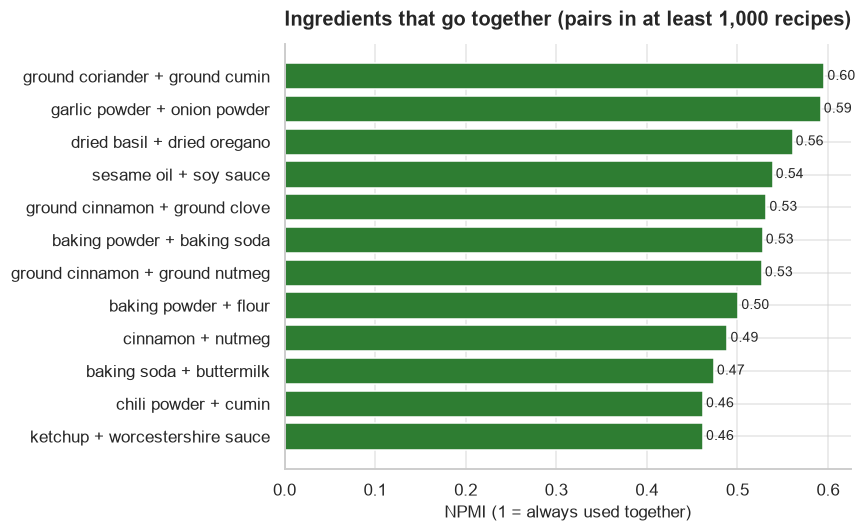

In [11]:
# Chart: the strongest common pairs overall (seen in at least 1,000 recipes)
common_pairs = pairings[(pairings["scope"] == "all") & (pairings["n_recipes"] >= 1000)].head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(common_pairs["ingredient_a"] + " + " + common_pairs["ingredient_b"], common_pairs["npmi"], color="#2E7D32")
label_bars(ax, fmt="{:.2f}")
ax.set_xlabel("NPMI (1 = always used together)")
ax.set_title("Ingredients that go together (pairs in at least 1,000 recipes)")
show_figure(fig, "nb04_01_pairings")

---

## 5. Shelf Life (USDA FoodKeeper)

**Source (checked 2026-10-04):** USDA FoodKeeper (Food Safety and Inspection Service), listed on data.gov
under **CC0** (public domain). It gives storage times in the pantry, refrigerator and freezer, from purchase,
after opening and after thawing, with tips. USDA's server refuses downloads from some networks (HTTP 403), so
`download_foodkeeper` falls back to the Internet Archive's copy of the same file (July 2025).

**Steps:** download the JSON file once, turn its times and units into days ("1-2 Weeks" -> 7-14), keep notes
such as "Not Recommended" or "When Ripe" as they are, and match FoodKeeper foods to our ingredient names:
`name` (the food's own name), `keyword` (one of its keywords) or `head` (only the last word matches:
"cheddar cheese" -> Cheese). `keyword` and `head` matches go to the hand check.

**Wording rule:** times are **guidance from USDA**, not a guarantee that food is safe ("USDA suggests
using it within 3-5 days").

In [12]:
foodkeeper = foodkeeper_table(download_foodkeeper(FOODKEEPER_DIR, refresh=REFRESH_DOWNLOADS))
shelf_matches = match_shelf_life(common_names, foodkeeper)
shelf_life = shelf_matches.merge(foodkeeper.drop(columns=["name", "product", "keywords"]), on="foodkeeper_id")
shelf_life.to_parquet(SHELF_LIFE_FILE, index=False)
print(f"FoodKeeper: {foodkeeper['foodkeeper_id'].nunique()} foods, {len(foodkeeper):,} storage times")
print(f"Matched {shelf_matches['ingredient'].nunique():,} of {len(common_names):,} common ingredients:")
print(shelf_matches["match"].value_counts().rename("ingredients").to_string())
print(f"Saved {len(shelf_life):,} rows to {SHELF_LIFE_FILE}")

FoodKeeper: 661 foods, 1,409 storage times
Matched 1,519 of 1,863 common ingredients:
match
head       1160
name        265
keyword      94
Saved 3,470 rows to data\processed\ingredient_shelf_life.parquet


In [13]:
# How an agent would word it (guidance, never a guarantee)
def usda_advice(ingredient):
    rows = shelf_life[(shelf_life["ingredient"] == ingredient) & shelf_life["min_days"].notna()]
    parts = []
    for r in rows.itertuples():
        days = f"{r.min_days:g}" if r.min_days == r.max_days else f"{r.min_days:g}-{r.max_days:g}"
        parts.append(f"{r.storage} ({r.condition}) {days} days")
    return f"USDA suggests: {'; '.join(parts)}" if parts else "No USDA storage time found"

for ingredient in ["milk", "chicken breast", "ground beef", "egg", "fresh spinach"]:
    print(f"{ingredient:15s} {usda_advice(ingredient)}")

milk            USDA suggests: freezer (from purchase) 90 days
chicken breast  USDA suggests: fridge (as sold) 1-2 days; freezer (as sold) 270 days
ground beef     USDA suggests: fridge (from purchase) 3-5 days; freezer (from purchase) 120-360 days
egg             USDA suggests: fridge (from purchase) 21-35 days
fresh spinach   No USDA storage time found


---

## 6. Team Decisions and Next Steps

1. **Pilot languages** (`PILOT_LANGUAGES`): should follow the pilot countries chosen in notebook 03.
2. **Hand checks:** who checks the `ranked` Wikidata matches (section 2), a blind sample of the substitution
   pairs (section 3) and the `keyword` / `head` shelf-life matches (section 5).
3. **Minimum counts** for names (`NAME_MIN_RECIPES`), swaps (`SUBSTITUTION_MIN_REVIEWS`) and pairings
   (`PAIR_MIN_RECIPES`).
4. **Open Food Facts taxonomy** as a second name source, once its license is confirmed.

---

## Plan status

What is built and what still needs a person.

In [14]:
PLAN = pd.DataFrame([
    ("2 Names across languages (Wikidata)", f"built: {ingredient_names['ingredient'].nunique():,} ingredients; ranked / head matches need a hand check"),
    ("3 Substitutions from reviews", f"built: {len(swaps):,} swaps; a sample needs a hand check"),
    ("4 Pairings (PMI)", f"built: {len(pairings):,} pairs"),
    ("5 Shelf life (FoodKeeper)", f"built: {shelf_matches['ingredient'].nunique():,} ingredients; keyword / head matches need a hand check"),
], columns=["step", "status"])
print(PLAN.to_string(index=False))

                               step                                                             status
2 Names across languages (Wikidata)  built: 1,511 ingredients; ranked / head matches need a hand check
       3 Substitutions from reviews                    built: 2,163 swaps; a sample needs a hand check
                   4 Pairings (PMI)                                               built: 105,642 pairs
          5 Shelf life (FoodKeeper) built: 1,519 ingredients; keyword / head matches need a hand check
